# W Pythonie porównaj wyniki regresji liniowej, Ridge, sieci neuronowych na tym samym zbiorze danych.


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [3]:
#tworzy przykladowy dataset dla problemu regresji
X_noisy, y_noisy = make_regression(
    n_samples=100,
    n_features=2,
    noise=0,
    random_state=42
)

In [11]:
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=0.5),
    'Lasso': Lasso(alpha=1.0)
}

results = {}
for name, model in models.items():
    model.fit(X_noisy, y_noisy)
    y_pred = model.predict(X_noisy)
    results[name] = {
        'R²': r2_score(y_noisy, y_noisy),
        'MSE': mean_squared_error(y_noisy, y_noisy),
        'MAE': mean_absolute_error(y_noisy, y_noisy),
        'model': model
    }
    print(f"{name}: R²={results[name]['R²']:.3f}, MSE={results[name]['MSE']:.2f}, MAE={results[name]['MAE']:.2f}")

Linear: R²=1.000, MSE=0.00, MAE=0.00
Ridge: R²=1.000, MSE=0.00, MAE=0.00
Lasso: R²=1.000, MSE=0.00, MAE=0.00



Ważność cech ridge: [87.15050374 73.71994737]

Ważność cech lasso: [86.39655484 73.10160235]


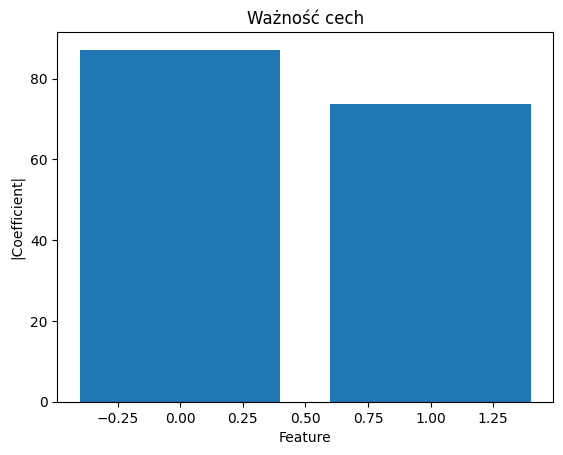

In [12]:
ridge = results['Ridge']['model']
feature_importance = np.abs(ridge.coef_)

lasso = results['Lasso']['model']
lasso_feature_importance = np.abs(lasso.coef_)

print("\nWażność cech ridge:", feature_importance)
print("\nWażność cech lasso:", lasso_feature_importance)

plt.bar(range(len(feature_importance)), feature_importance)
plt.xlabel('Feature')
plt.ylabel('|Coefficient|')
plt.title('Ważność cech')
plt.show()


# Wykonaj analizę reszt dla modelu regresji liniowej:
    -Sprawdź założenie normalności błędów,
    -Zbadaj autokorelację reszt test Durbin-Watson

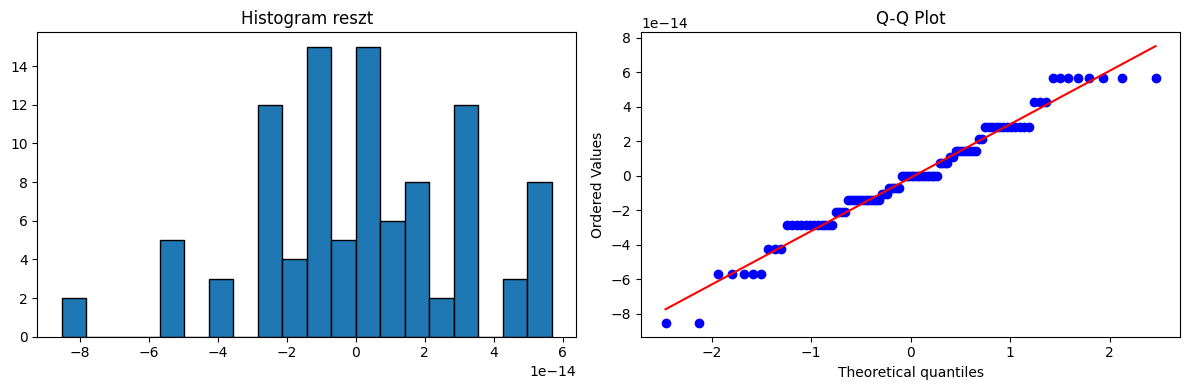


Shapiro-Wilk: stat=0.9709, p=0.0259 (brak normalności)
Durbin-Watson: 1.9776 (brak autokorelacji ≈ 2.0)


In [13]:
from scipy import stats

residuals = y_noisy - results['Linear']['model'].predict(X_noisy)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=20, edgecolor='black')
plt.title('Histogram reszt')
plt.subplot(1, 2, 2)

stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.tight_layout()
plt.show()

#shapiro (rozklad gausa/normalny) - p > 0.05 → OK (reszty są ~normalne) p ≤ 0.05 → problem (reszty nie są normalne)
#W regresji liniowej zakłada się, że błędy są normalne (ważne np. dla testów statystycznych i przedziałów ufności).

#durbin_watson - Czy reszty są autokorelowane (czy zależą od siebie w czasie).
#~2 → brak autokorelacji , < 2 → dodatnia autokorelacja , > 2 → ujemna autokorelacja 

stat, p = shapiro(residuals)
dw_stat = durbin_watson(residuals)
print(f"\nShapiro-Wilk: stat={stat:.4f}, p={p:.4f} {'(normalność OK)' if p > 0.05 else '(brak normalności)'}")
print(f"Durbin-Watson: {dw_stat:.4f} (brak autokorelacji ≈ 2.0)")

# Porównaj jakość modeli przy użyciu danych o różnych skalach (np. znormalizowanych i oryginalnych).

Epoch 20/20, Train Loss: 100.0706, Val Loss: 102.6104

Sieć neuronowa MAE: 7.810


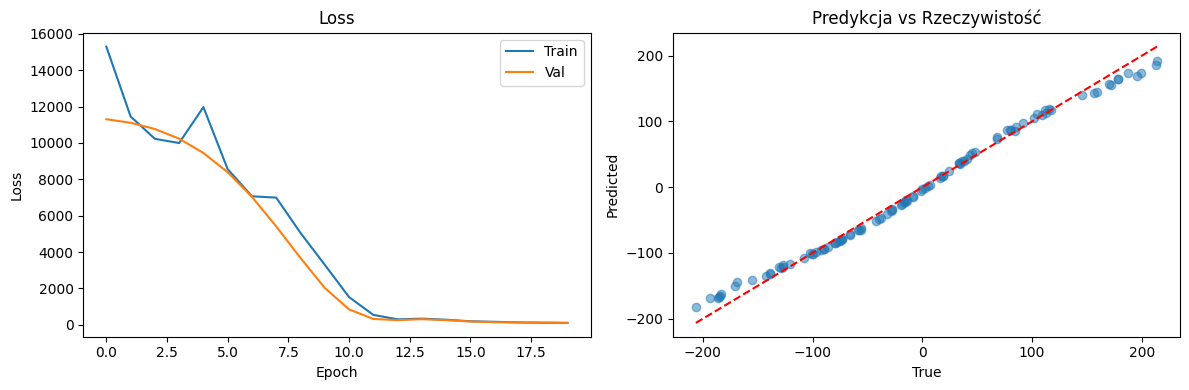

In [14]:
#flatten zamienia (100,) # wektor 1D na (100, 1) # kolumna (2D)
X_train_scaled = X_noisy
X_test_scaled = X_noisy
y_train_scaled = y_noisy.reshape(-1, 1).flatten()
y_test_scaled = y_noisy.reshape(-1, 1).flatten()

#zamiana np.array([[1., -1.]]) na tensor([ 1.0000, -1.0000])
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#shuffle=True losowo mieszane dane 
# permutacja inne ułożenie tych samych elementów
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        #To wywołuje konstruktor klasy bazowej (nn.Module).  Bez tego PyTorch:  nie zarejestruje warstw
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        #squeeze usuwa zbeden wymiary
        #tensor([[2.5],[3.1],[1.8]])   # bez squeeze shape: (3, 1)
        #tensor([2.5, 3.1, 1.8])   # z squeeze shape: (3,)
        return x.squeeze()

model = RegressionNN(X_noisy.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        #zeruje stare gradienty PyTorch domyślnie sumuje gradienty z poprzednich kroków.
        optimizer.zero_grad()
        #forward pass (przejście do przodu) przepuszcza przez warstwy daje predykcję
        outputs = model(X_batch)
        #pewnie mse albo mae
        loss = criterion(outputs, y_batch)
        #backpropagation (wsteczna propagacja błędu)
        loss.backward()
        #aktualizacja wag
        optimizer.step()
        #zbieranie błędu do statystyk
        epoch_loss += loss.item()

    #tryb testowania wylacza dropout (losowe wyłączanie neuronów) uczenie batch normalization
    model.eval()
    #nie licz gradientów - bo nie uczysz modelu
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_loss = criterion(val_pred, y_test_tensor)
        
    #zapisujesz średni błąd treningowy z epoki
    train_losses.append(epoch_loss / len(train_loader))
    val_losses.append(val_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_mae = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f"\nSieć neuronowa MAE: {test_mae:.3f}")

# Wizualizacja
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.scatter(y_test_scaled, predictions.numpy(), alpha=0.5)
plt.plot([y_test_scaled.min(), y_test_scaled.max()],
         [y_test_scaled.min(), y_test_scaled.max()], 'r--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Predykcja vs Rzeczywistość')
plt.tight_layout()
plt.show()

Epoch 20/20, Train Loss: 0.0006, Val Loss: 0.0006

Sieć neuronowa MAE: 0.014


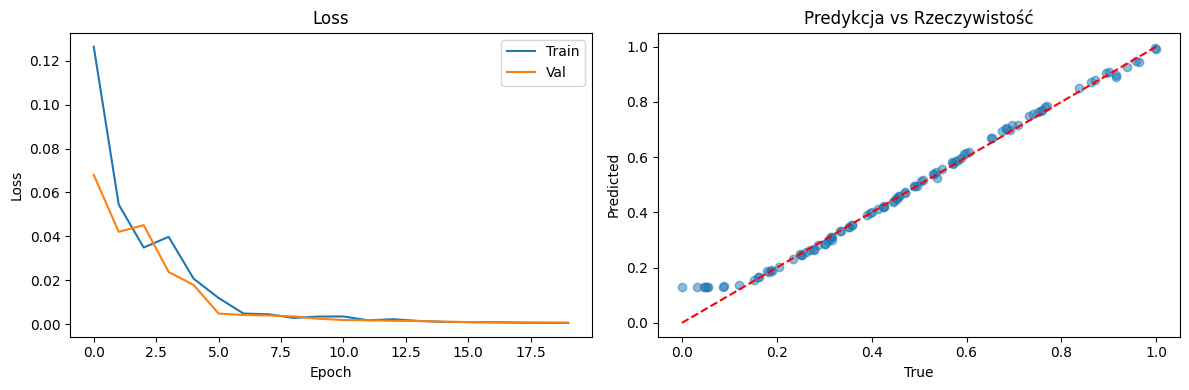

In [18]:
#normalizacja danych x' = (x - min) / (max - min)  centrowanie + skala
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

#flatten zamienia (100,) # wektor 1D na (100, 1) # kolumna (2D)
X_train_scaled = scaler_X.fit_transform(X_noisy)
X_test_scaled = scaler_X.transform(X_noisy)
y_train_scaled = scaler_y.fit_transform(y_noisy.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_noisy.reshape(-1, 1)).flatten()

#zamiana np.array([[1., -1.]]) na tensor([ 1.0000, -1.0000])
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test_scaled)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#shuffle=True losowo mieszane dane 
# permutacja inne ułożenie tych samych elementów
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        #To wywołuje konstruktor klasy bazowej (nn.Module).  Bez tego PyTorch:  nie zarejestruje warstw
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        #squeeze usuwa zbeden wymiary
        #tensor([[2.5],[3.1],[1.8]])   # bez squeeze shape: (3, 1)
        #tensor([2.5, 3.1, 1.8])   # z squeeze shape: (3,)
        return x.squeeze()

model = RegressionNN(X_noisy.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        #zeruje stare gradienty PyTorch domyślnie sumuje gradienty z poprzednich kroków.
        optimizer.zero_grad()
        #forward pass (przejście do przodu) przepuszcza przez warstwy daje predykcję
        outputs = model(X_batch)
        #pewnie mse albo mae
        loss = criterion(outputs, y_batch)
        #backpropagation (wsteczna propagacja błędu)
        loss.backward()
        #aktualizacja wag
        optimizer.step()
        #zbieranie błędu do statystyk
        epoch_loss += loss.item()

    #tryb testowania wylacza dropout (losowe wyłączanie neuronów) uczenie batch normalization
    model.eval()
    #nie licz gradientów - bo nie uczysz modelu
    with torch.no_grad():
        val_pred = model(X_test_tensor)
        val_loss = criterion(val_pred, y_test_tensor)
        
    #zapisujesz średni błąd treningowy z epoki
    train_losses.append(epoch_loss / len(train_loader))
    val_losses.append(val_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")

model.eval()
with torch.no_grad():
    predictions = model(X_test_tensor)
    test_mae = torch.mean(torch.abs(predictions - y_test_tensor))
    print(f"\nSieć neuronowa MAE: {test_mae:.3f}")

# Wizualizacja
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.scatter(y_test_scaled, predictions.numpy(), alpha=0.5)
plt.plot([y_test_scaled.min(), y_test_scaled.max()],
         [y_test_scaled.min(), y_test_scaled.max()], 'r--')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Predykcja vs Rzeczywistość')
plt.tight_layout()
plt.show()